# SOM（自组织映射）完整学习指南

SOM（Self-Organizing Map，自组织映射）是一种非常特别的无监督学习算法。
如果说K-Means是"把数据分成K堆"，那SOM就是"把数据铺在一张地图上，让相似的数据挨在一起"。

---

## 一、SOM是什么？——核心思想一句话

**SOM是一种能将高维数据映射到低维空间（通常是二维网格），并保持数据之间拓扑关系的神经网络。**

"拓扑关系"是关键——用通俗的话说：
- **在原始高维空间中相似的数据** → **在SOM地图上也会靠得很近**
- **在原始空间中不相似的数据** → **在地图上会离得很远**

这让人联想到大脑的"皮质地图"——手指的感觉区挨在一起，脚的感觉区挨在一起，身体各部位在大脑皮层上形成一张有空间关系的"地图"。

---

## 二、SOM与K-Means的本质区别

| 维度 | K-Means | SOM |
|------|---------|-----|
| **本质** | 纯聚类算法 | 神经网络 + 聚类 + 可视化 |
| **输出** | 每个点所属的簇标签 | 每个点在二维地图上的位置 |
| **拓扑关系** | 不保持 | **保持**（相似数据位置靠近） |
| **K值/网格大小** | 需要指定K | 需要指定网格大小（可大于实际簇数） |
| **邻近更新** | 只更新获胜簇 | **更新获胜节点及其邻居** |
| **可视化能力** | 弱 | **强**（可画U-matrix、分量平面等） |
| **"死节点"问题** | 无 | 可能存在永不获胜的神经元 |

**最大的区别**：K-Means只更新获胜的那个簇，而SOM会"连坐"——获胜节点周围的邻居也会被更新，只是幅度小一些。这个机制让SOM能保持拓扑结构。

---

## 三、SOM的网络结构

SOM的结构非常简单，只有两层：

```
输入层                    竞争层（输出层/地图）
┌─────┐                 ┌───┬───┬───┐
│ x₁  ├────────────────►│   │   │   │
├─────┤                 ├───┼───┼───┤
│ x₂  ├────────────────►│   │ ● │   │  ← 二维网格
├─────┤                 ├───┼───┼───┤
│ ... │                 │   │   │   │
├─────┤                 └───┴───┴───┘
│ x_d  │                 每个格子 = 一个神经元
└─────┘                  = 一个聚类中心
```

- **输入层**：神经元数量 = 数据的维度（d）
- **竞争层**：通常是一个二维网格，每个格子代表一个"神经元/聚类中心"
- **全连接**：每个输入神经元连接到所有输出神经元

网格可以是矩形或六边形——六边形更接近生物学发现。

---

## 四、SOM的训练过程（用餐厅类比）

### 场景设定
想象你开了一家连锁餐厅，想把菜单上的100道菜（高维数据）归类到一张2x2的宣传单上（二维地图），希望口味相似的菜放在靠近的格子。

以下是训练过程：

**步骤1：初始化**
给地图上每个格子随机分配一道"代表菜"（初始权重）。此时毫无章法。

**步骤2：输入一个数据**
拿起一道佛跳墙，比较它与每个格子代表菜的"距离"，找到口味最接近的格子——这就是**获胜节点（BMU, Best Matching Unit）**。

**步骤3：更新权重**
把真正佛跳墙的配方"教"给获胜格子及其周围的邻居：
- 获胜格子：学得最快（变化最大）
- 近邻格子：也学，但慢一点
- 远邻格子：不学

更新公式：
```
w_new = w_old + η × h × (数据 - w_old)
```
- η：学习率（随时间减小）
- h：邻域折扣（离获胜节点越远，值越小）

**步骤4：重复**
拿下一道菜，重复2-3步。

**步骤5：逐渐缩小"邻域"**
开始时更新范围大（宏观调整），逐渐缩小到只更新获胜格子自己（微观精调）。

**步骤6：收敛**
经过成百上千轮，地图稳定——每类菜固定出现在地图的特定区域。

---

## 五、常见可视化方法

SOM的强大之处在于丰富的可视化手段：

**1. U-Matrix（统一距离矩阵）**
显示地图上相邻神经元之间的"距离"。颜色越深表示距离越大——这些深色区域就是不同簇之间的**边界**。U-Matrix能帮你"看出"自然形成的簇。

**2. 成分平面图（Component Planes）**
每个特征单独画一张地图，显示该特征在地图上的分布。帮助理解哪些特征驱动了聚类。

**3. 命中频率图**
统计有多少数据点被映射到地图的每个格子，快速识别"热门"区域。

---

## 六、SOM vs. K-Means：如何选择？

| 任务场景 | 推荐算法 | 原因 |
|---------|---------|------|
| 只要**干净利落的分类** | K-Means | 更快、更直接 |
| 想**理解数据结构+分类** | SOM | 可视化强大 |
| 数据**高维、想降维** | SOM | 天然降维到2D |
| 需要**保持拓扑关系** | SOM | K-Means做不到 |
| 预设K有**明确业务含义** | K-Means | SOM网格≠簇数 |
| 数据有**噪声** | SOM | 邻域更新更鲁棒 |

**实际应用中**：两者常**混合使用**——先用SOM降维可视化、理解结构，然后在SOM网格上做K-Means二次聚类。

如人口地理分析：先用SOM将高维普查数据映射到二维网格，再对网格节点聚类，最终得到更好解读的地理分区。

---

## 七、SOM的局限性

没有任何算法是完美的：

1. **网络结构固定**：训练前必须指定网格大小，不能动态调整
2. **"死神经元"问题**：部分节点始终无法获胜，成为"摆设"
3. **参数敏感**：初始权重、学习率、邻域半径极大影响结果
4. **无法增量学习**：加入新类别需重新训练

改进方向：Growing SOM（可生长）、Conscience SOM（防死神经元）等。

---

## 八、思考题

学完SOM后，试着回答几个问题：

1. **如果你有10维数据但只想用SOM做聚类，网格尺寸设多少合适？**
   - 网格大小和最终簇数无直接关系。可以用U-Matrix观察"自然形成的边界"来决定二次聚类的K值。

2. **SOM为什么比K-Means更能抵抗噪声？**
   - 因邻域机制——噪声点会影响获胜节点及其邻居，单点影响被"分摊"，不会剧烈改变单一簇中心。

3. **什么时候宁可用K-Means也不用SOM？**
   - 数据量极大（百万级）、不需要可视化、K有明确业务含义、只需干净分类标签时。

---

SOM最独特的价值是让"聚类结果可见"——帮你"看见"高维数据的结构。建议先用`minisom`跑一个简单数据集（如Iris），画出U-Matrix和分量平面图，亲自体验"让数据自己说话"的感觉。

Training SOM...
SOM training complete!

Mapping samples to BMUs...

Clustering BMU coordinates...

Evaluation Results
Adjusted Rand Index (ARI): 0.5275
Normalized Mutual Info (NMI): 0.6002


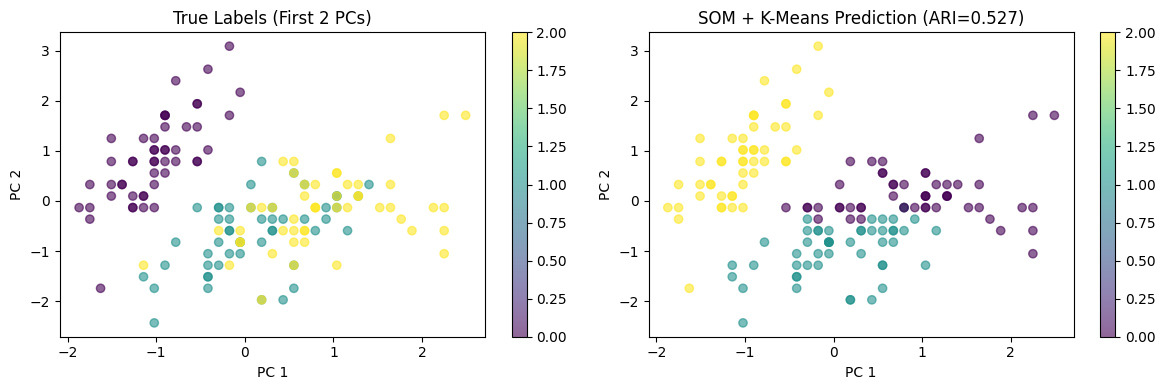


Generating U-Matrix...


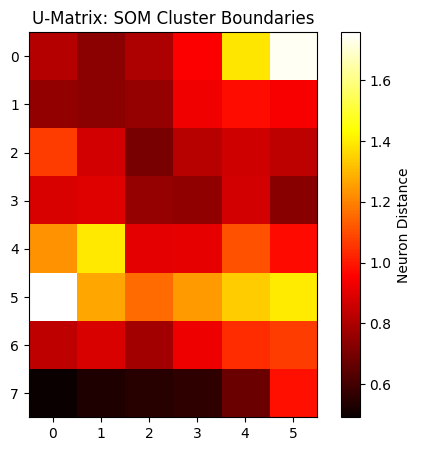

In [1]:
# 推荐方式（模拟 sklearn 接口 + torchsom 核心）
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. 加载数据
iris = load_iris()
X = iris.data
y_true = iris.target

# 2. 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 转换为 PyTorch 张量
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# 4. 配置 SOM 参数
grid_height, grid_width = 8, 6      # 8x6 网格
input_dim = X.shape[1]               # 4 维
learning_rate = 0.5
neighborhood_radius = 2.0
epochs = 500

# 5. 初始化 SOM 权重（均匀初始化效果优于随机）
som_weights = torch.randn(grid_height, grid_width, input_dim) * 0.01

# 6. 训练 SOM（小型数据集，用简单循环）
print("Training SOM...")

# 预先计算网格坐标（用于邻域距离计算）
grid_y, grid_x = torch.meshgrid(torch.arange(grid_height), 
                                 torch.arange(grid_width), 
                                 indexing='ij')
grid_coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1).float()  # [HW, 2]

for epoch in range(epochs):
    # 动态调整学习率和邻域半径
    lr = learning_rate * (1 - epoch / epochs)  # 线性衰减
    
    # 对每个样本进行训练（可以改写为批量，简单起见保留循环）
    for i, x in enumerate(X_tensor):
        # 展平 SOM 权重 [HW, D]
        som_flat = som_weights.view(-1, input_dim)  # [HW, D]
        
        # 计算到所有神经元的距离
        # 方法：dist = ||x - w||^2
        diff = som_flat - x.unsqueeze(0)  # [HW, D]
        distances = torch.sum(diff**2, dim=1)  # [HW]
        
        # 找到 BMU 索引
        bmu_idx = torch.argmin(distances).item()
        bmu_coord = grid_coords[bmu_idx]  # [2]
        
        # 计算所有神经元到 BMU 的网格欧氏距离
        grid_distances = torch.norm(grid_coords - bmu_coord, dim=1)  # [HW]
        
        # 高斯邻域函数
        sigma_sq = 2.0 * (neighborhood_radius * (1 - epoch / epochs))**2
        neighborhood = torch.exp(-grid_distances**2 / sigma_sq)  # [HW]
        
        # 更新权重： Δw = lr × neigh × (x - w)
        update = lr * neighborhood.unsqueeze(1) * (x.unsqueeze(0) - som_flat)
        som_flat += update
        som_weights = som_flat.view(grid_height, grid_width, input_dim)

print("SOM training complete!")

# 7. 获取每个样本的 BMU 坐标
print("\nMapping samples to BMUs...")
bmu_coords = []

for x in X_tensor:
    som_flat = som_weights.view(-1, input_dim)
    diff = som_flat - x.unsqueeze(0)
    distances = torch.sum(diff**2, dim=1)
    bmu_idx = torch.argmin(distances).item()
    bmu_coords.append(grid_coords[bmu_idx].numpy())

bmu_coords = np.array(bmu_coords)

# 8. 对 BMU 坐标进行 K-Means 聚类
print("\nClustering BMU coordinates...")
n_clusters = 3  # 已知 Iris 有 3 类
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_pred = kmeans.fit_predict(bmu_coords)

# 9. 评估与可视化
print("\n" + "="*50)
print("Evaluation Results")
print("="*50)

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

# 10. 可视化
plt.figure(figsize=(12, 4))

# 左图：真实标签
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], 
                       c=y_true, cmap='viridis', alpha=0.6)
plt.title('True Labels (First 2 PCs)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar(scatter1)

# 右图：SOM+KMeans 预测
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], 
                       c=y_pred, cmap='viridis', alpha=0.6)
plt.title(f'SOM + K-Means Prediction (ARI={ari:.3f})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar(scatter2)

plt.tight_layout()
plt.show()

# 11. 显示 U-Matrix（可视化地图边界）
print("\nGenerating U-Matrix...")
som_flat = som_weights.view(-1, input_dim)
u_matrix = np.zeros((grid_height, grid_width))

for i in range(grid_height):
    for j in range(grid_width):
        neighbors = []
        # 8-邻域
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < grid_height and 0 <= nj < grid_width:
                dist = torch.norm(som_weights[i,j] - som_weights[ni,nj]).item()
                neighbors.append(dist)
        u_matrix[i,j] = np.mean(neighbors) if neighbors else 0

plt.figure(figsize=(6, 5))
plt.imshow(u_matrix, cmap='hot', origin='upper')
plt.colorbar(label='Neuron Distance')
plt.title('U-Matrix: SOM Cluster Boundaries')
plt.show()